# Automated Essay Scoring (AES)
**Model:** IndoBERT (`indobenchmark/indobert-base-p1`) + Cosine Similarity

## 1. Instalasi Library

In [ ]:
!pip install transformers torch openpyxl pandas numpy scikit-learn matplotlib seaborn tqdm
!pip install accelerate pingouin

## 2. Import Library

In [ ]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from tqdm.auto import tqdm
from scipy import stats

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics.pairwise import cosine_similarity, cosine_similarity as cos_sim_matrix
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import pingouin as pg

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 3. Konfigurasi Global

In [ ]:
DATASET_PATH        = 'dataset_esaisejarah11.xlsx'
VALIDATION_PATH     = 'Dokumen Validasi Nilai Esai Sejarah FIX.xlsx'
INDOBERT_MODEL_NAME = 'indobenchmark/indobert-base-p1'
EMBEDDING_STRATEGY  = 'mean_pooling'
BATCH_SIZE          = 16
MAX_LENGTH          = 256
CACHE_DIR           = './embedding_cache'
SCORE_MIN, SCORE_MAX = 0, 100
THRESHOLD_TINGGI    = 80
THRESHOLD_SEDANG    = 60
THRESHOLD_RENDAH    = 40

os.makedirs(CACHE_DIR, exist_ok=True)
print('Konfigurasi dimuat.')
print(f'  Model     : {INDOBERT_MODEL_NAME}')
print(f'  Strategi  : {EMBEDDING_STRATEGY}')
print(f'  Batch     : {BATCH_SIZE}  |  Max length: {MAX_LENGTH}')

Konfigurasi dimuat.
  Model     : indobenchmark/indobert-base-p1
  Strategi  : mean_pooling
  Batch     : 16  |  Max length: 256


## 4. Load dan Eksplorasi Dataset

In [ ]:
df = pd.read_excel(DATASET_PATH)

print(f'Jumlah baris   : {len(df):,}')
print(f'Jumlah kolom   : {len(df.columns)}')
print(f'Kolom          : {df.columns.tolist()}')
print(f'Jumlah siswa   : {df["nama"].nunique()}')
print(f'Kelas          : {df["kelas"].unique().tolist()}')
print(f'Topik          : {df["topik"].unique().tolist()}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplikat       : {df.duplicated().sum()}')
df.head(3)

Jumlah baris   : 1,175
Jumlah kolom   : 7
Kolom          : ['nama', 'kelas', 'topik', 'id_pertanyaan', 'pertanyaan', 'jawaban_siswa', 'kunci_jawaban']
Jumlah siswa   : 123
Kelas          : ['XI TP', 'XI TMI 2', 'XI TMI 1', 'XI TKRO']
Topik          : ['Kolonialisme & Pergerakan Nasional', 'Pendudukan Jepang']
Missing values : 0
Duplikat       : 0


,nama,kelas,topik,id_pertanyaan,pertanyaan,jawaban_siswa,kunci_jawaban
0,Abdurrahman M Syafik,XI TP,Kolonialisme & Pergerakan Nasional,1,Terangkan tentang kolonialisme !,Kolonialisme adalah sistem penguasaan negara asing kepada wilayah lain untuk...,Kolonialisme adalah sebuah paham atau upaya suatu negara untuk menguasai dan...
1,Abdurrahman M Syafik,XI TP,Kolonialisme & Pergerakan Nasional,2,Jelaskan tindakan yang dilakukan VOC dalam melaksanakan monopoli perdagangan !,"Kontrak monopoli, tanam paksa, pengawasan ketat harga dagang",Ekstirpasi yaitu menebang atau memusnahkan tanaman rempah-rempah milik pendu...
2,Abdurrahman M Syafik,XI TP,Kolonialisme & Pergerakan Nasional,3,Sebutkan minimal 5 dampak positif dan negatif penjajahan terhadap masyarakat...,"Dampak positif : infrastruktur, pendidikan modern, semangat nasionalisme yan...","Dampak positif penjajahan: Pembangunan infrastruktur masif, lahirnya golonga..."


In [ ]:
distribusi = df.groupby(['topik', 'id_pertanyaan']).size().reset_index(name='jumlah_jawaban')
print(distribusi.to_string(index=False))
print()
print(df.groupby('kelas').size().reset_index(name='jumlah_jawaban').to_string(index=False))

                             topik  id_pertanyaan  jumlah_jawaban
Kolonialisme & Pergerakan Nasional              1             112
Kolonialisme & Pergerakan Nasional              2             112
Kolonialisme & Pergerakan Nasional              3             112
Kolonialisme & Pergerakan Nasional              4             112
Kolonialisme & Pergerakan Nasional              5             112
                 Pendudukan Jepang              1             123
                 Pendudukan Jepang              2             123
                 Pendudukan Jepang              3             123
                 Pendudukan Jepang              4             123
                 Pendudukan Jepang              5             123

   kelas  jumlah_jawaban
 XI TKRO             305
XI TMI 1             305
XI TMI 2             340
   XI TP             225


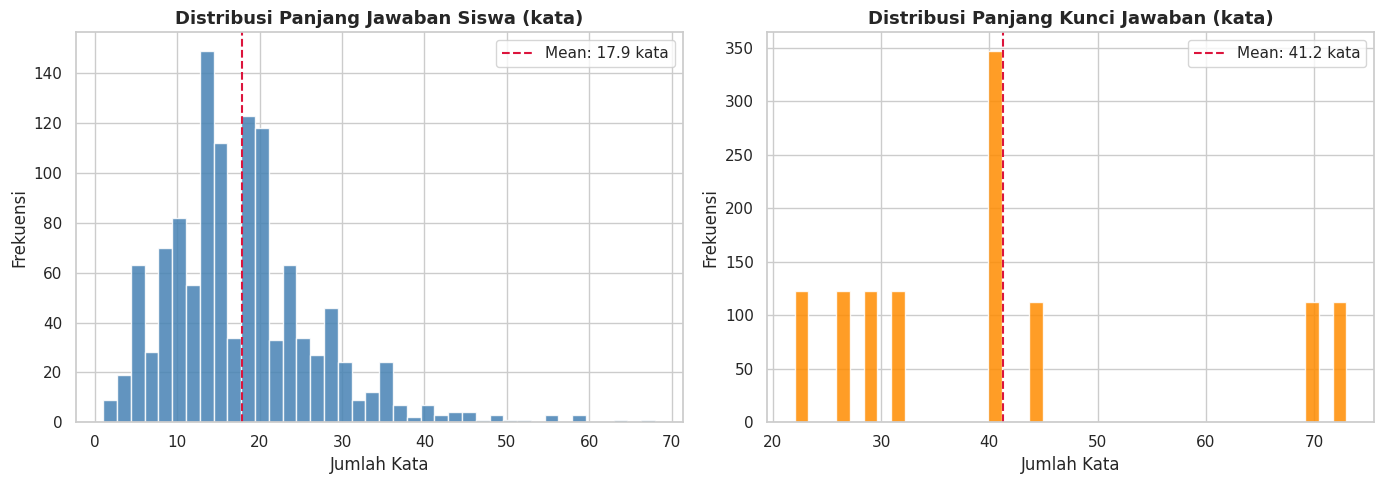

In [ ]:
df['panjang_jawaban_siswa'] = df['jawaban_siswa'].str.split().str.len()
df['panjang_kunci_jawaban'] = df['kunci_jawaban'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label, color in zip(
    axes,
    ['panjang_jawaban_siswa', 'panjang_kunci_jawaban'],
    ['Jawaban Siswa', 'Kunci Jawaban'],
    ['steelblue', 'darkorange']
):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='crimson', linestyle='--',
               label=f'Mean: {df[col].mean():.1f} kata')
    ax.set_title(f'Distribusi Panjang {label} (kata)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Jumlah Kata')
    ax.set_ylabel('Frekuensi')
    ax.legend()
plt.tight_layout()
plt.savefig('distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocessing Teks

In [ ]:
class TextPreprocessor:
    def clean(self, text: str) -> str:
        if not isinstance(text, str) or not text.strip():
            return ''
        text = text.lower()
        text = re.sub(r'\s+', ' ', text).strip()
        text = re.sub(r'[^\w\s.,!?:;\-]', '', text)
        return re.sub(r'\s+', ' ', text).strip()

    def preprocess_batch(self, texts: list) -> list:
        return [self.clean(t) for t in texts]


preprocessor = TextPreprocessor()
df['jawaban_siswa_bersih'] = preprocessor.preprocess_batch(df['jawaban_siswa'].tolist())
df['kunci_jawaban_bersih'] = preprocessor.preprocess_batch(df['kunci_jawaban'].tolist())

print(f'Teks siswa kosong : {(df["jawaban_siswa_bersih"] == "").sum()}')
print(f'Teks kunci kosong : {(df["kunci_jawaban_bersih"] == "").sum()}')

Teks siswa kosong : 0
Teks kunci kosong : 0


## 6. IndoBERT — Load Model dan Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(INDOBERT_MODEL_NAME)
model_indobert = AutoModel.from_pretrained(INDOBERT_MODEL_NAME).to(DEVICE)
model_indobert.eval()

print(f'Model dimuat ke: {DEVICE}')
print(f'  Parameter : {sum(p.numel() for p in model_indobert.parameters()):,}')
print(f'  Hidden    : {model_indobert.config.hidden_size}')
print(f'  Layers    : {model_indobert.config.num_hidden_layers}')
print(f'  Vocab     : {model_indobert.config.vocab_size:,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model dimuat ke: cuda
  Parameter : 124,441,344
  Hidden    : 768
  Layers    : 12
  Vocab     : 50,000


In [ ]:
def get_indobert_embeddings(texts, tokenizer, model, device,
                             batch_size=BATCH_SIZE, max_length=MAX_LENGTH,
                             strategy=EMBEDDING_STRATEGY):
    all_embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({strategy})', unit='batch'):
            encoded = tokenizer(
                texts[i:i + batch_size],
                padding=True, truncation=True,
                max_length=max_length, return_tensors='pt'
            )
            input_ids      = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask'].to(device)
            token_type_ids = encoded.get('token_type_ids')
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                            token_type_ids=token_type_ids)

            if strategy == 'cls':
                embeddings = outputs.last_hidden_state[:, 0, :]
            else:
                token_emb    = outputs.last_hidden_state
                mask_exp     = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
                embeddings   = torch.sum(token_emb * mask_exp, dim=1) / \
                               torch.clamp(mask_exp.sum(dim=1), min=1e-9)

            all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

## 7. Generate Embedding IndoBERT

In [ ]:
cache_siswa = os.path.join(CACHE_DIR, f'emb_jawaban_siswa_{EMBEDDING_STRATEGY}.npy')
cache_kunci  = os.path.join(CACHE_DIR, f'emb_kunci_jawaban_{EMBEDDING_STRATEGY}.npy')

if os.path.exists(cache_siswa):
    embeddings_siswa = np.load(cache_siswa)
    print(f'Cache dimuat: {cache_siswa}')
else:
    embeddings_siswa = get_indobert_embeddings(
        df['jawaban_siswa_bersih'].tolist(), tokenizer, model_indobert, DEVICE)
    np.save(cache_siswa, embeddings_siswa)
print(f'Shape embedding siswa : {embeddings_siswa.shape}')

if os.path.exists(cache_kunci):
    embeddings_kunci = np.load(cache_kunci)
    print(f'Cache dimuat: {cache_kunci}')
else:
    embeddings_kunci = get_indobert_embeddings(
        df['kunci_jawaban_bersih'].tolist(), tokenizer, model_indobert, DEVICE)
    np.save(cache_kunci, embeddings_kunci)
print(f'Shape embedding kunci : {embeddings_kunci.shape}')

Encoding (mean_pooling):   0%|          | 0/74 [00:00<?, ?batch/s]

Shape embedding siswa : (1175, 768)


Encoding (mean_pooling):   0%|          | 0/74 [00:00<?, ?batch/s]

Shape embedding kunci : (1175, 768)


In [ ]:
print(f'NaN siswa  : {np.isnan(embeddings_siswa).any()}')
print(f'NaN kunci  : {np.isnan(embeddings_kunci).any()}')
print(f'L2 siswa   : {np.linalg.norm(embeddings_siswa, axis=1).mean():.4f}')
print(f'L2 kunci   : {np.linalg.norm(embeddings_kunci, axis=1).mean():.4f}')
print(f'Dimensi    : {embeddings_siswa.shape[1]}')

NaN siswa  : False
NaN kunci  : False
L2 siswa   : 17.0315
L2 kunci   : 15.5581
Dimensi    : 768


## 8. Cosine Similarity — Perhitungan Skor AES

$$\\text{cosine\_similarity}(A, B) = \\frac{A \\cdot B}{\\|A\\| \\|B\\|}$$

$$\\text{skor} = \\text{cosine\_similarity} \\times 100$$

| Rentang Skor | Kategori |
|:---:|:---|
| 80–100 | Sangat Sesuai |
| 60–79 | Cukup Sesuai |
| 40–59 | Kurang Sesuai |
| 0–39 | Tidak Sesuai |

In [ ]:
cos_sim_raw = np.array([
    cosine_similarity(
        embeddings_siswa[i].reshape(1, -1),
        embeddings_kunci[i].reshape(1, -1)
    )[0][0]
    for i in range(len(df))
])
cos_sim_clipped = np.clip(cos_sim_raw, 0, 1)
skor_aes = (cos_sim_clipped * 100).round(2)

df['cosine_similarity'] = cos_sim_clipped.round(6)
df['skor_aes']          = skor_aes

print(f'Min  : {cos_sim_clipped.min():.4f}  |  Max  : {cos_sim_clipped.max():.4f}')
print(f'Mean : {cos_sim_clipped.mean():.4f}  |  Std  : {cos_sim_clipped.std():.4f}')

Min  : 0.2755  |  Max  : 0.9632
Mean : 0.7520  |  Std  : 0.1067


In [ ]:
def kategorikan_skor(skor):
    if skor >= THRESHOLD_TINGGI:  return 'Sangat Sesuai'
    elif skor >= THRESHOLD_SEDANG: return 'Cukup Sesuai'
    elif skor >= THRESHOLD_RENDAH: return 'Kurang Sesuai'
    return 'Tidak Sesuai'

df['kategori'] = df['skor_aes'].apply(kategorikan_skor)

total = len(df)
for kat, jml in df['kategori'].value_counts().items():
    pct = jml / total * 100
    print(f'  {kat:<18}: {jml:>4} ({pct:5.1f}%) {"█" * int(pct / 2)}')

  Cukup Sesuai      :  661 ( 56.3%) ████████████████████████████
  Sangat Sesuai     :  422 ( 35.9%) █████████████████
  Kurang Sesuai     :   84 (  7.1%) ███
  Tidak Sesuai      :    8 (  0.7%) 


## 9. Visualisasi Hasil Scoring

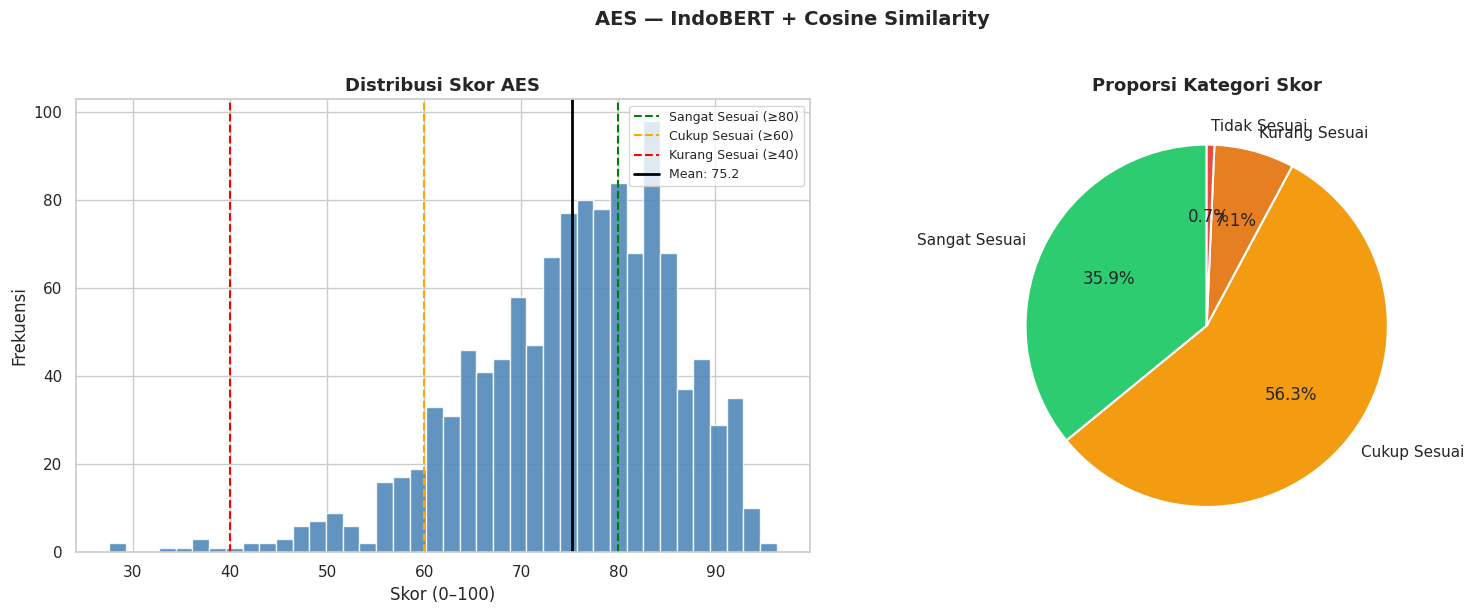

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['skor_aes'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
for thr, col, lbl in [
    (THRESHOLD_TINGGI, 'green',  f'Sangat Sesuai (≥{THRESHOLD_TINGGI})'),
    (THRESHOLD_SEDANG, 'orange', f'Cukup Sesuai (≥{THRESHOLD_SEDANG})'),
    (THRESHOLD_RENDAH, 'red',    f'Kurang Sesuai (≥{THRESHOLD_RENDAH})'),
]:
    axes[0].axvline(thr, color=col, linestyle='--', linewidth=1.5, label=lbl)
axes[0].axvline(df['skor_aes'].mean(), color='black', linestyle='-', linewidth=2,
                label=f'Mean: {df["skor_aes"].mean():.1f}')
axes[0].set_title('Distribusi Skor AES', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Skor (0–100)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

kategori_order = ['Sangat Sesuai', 'Cukup Sesuai', 'Kurang Sesuai', 'Tidak Sesuai']
warna_pie = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
nilai_pie = [df['kategori'].value_counts().get(k, 0) for k in kategori_order]
axes[1].pie(nilai_pie, labels=kategori_order, colors=warna_pie,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Kategori Skor', fontsize=13, fontweight='bold')

plt.suptitle('AES — IndoBERT + Cosine Similarity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_skor_aes.png', dpi=150, bbox_inches='tight')
plt.show()

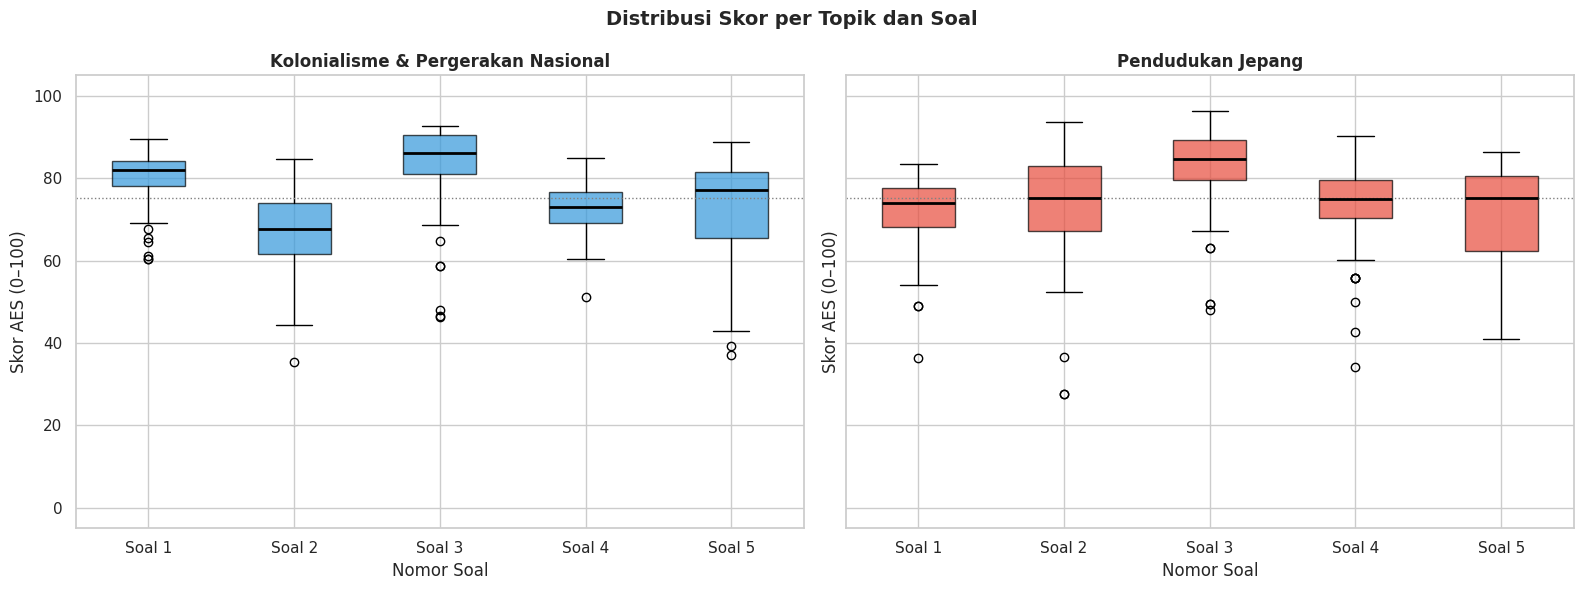

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
topik_list = df['topik'].unique()
warna_topik = ['#3498db', '#e74c3c']

for idx, (topik, ax) in enumerate(zip(topik_list, axes)):
    sub = df[df['topik'] == topik]
    data_per_soal = [sub[sub['id_pertanyaan'] == q]['skor_aes'].values
                     for q in sorted(sub['id_pertanyaan'].unique())]
    bp = ax.boxplot(data_per_soal, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch in bp['boxes']:
        patch.set_facecolor(warna_topik[idx])
        patch.set_alpha(0.7)
    ax.set_title(f'{topik}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Nomor Soal')
    ax.set_ylabel('Skor AES (0–100)')
    ax.set_xticklabels([f'Soal {q}' for q in sorted(sub['id_pertanyaan'].unique())])
    ax.axhline(df['skor_aes'].mean(), color='gray', linestyle=':', linewidth=1)
    ax.set_ylim(-5, 105)

plt.suptitle('Distribusi Skor per Topik dan Soal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('skor_per_topik_soal.png', dpi=150, bbox_inches='tight')
plt.show()

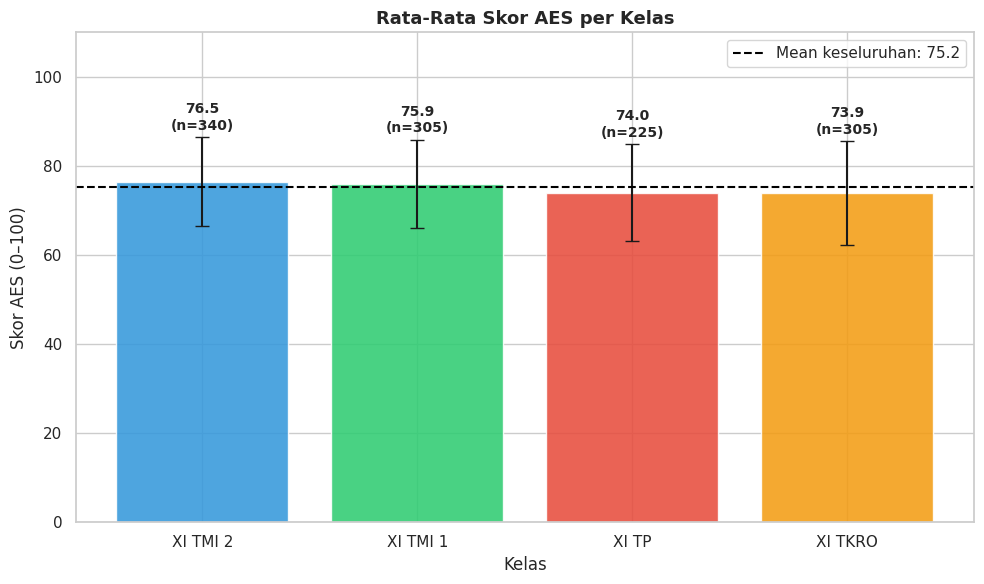

In [ ]:
skor_per_kelas = df.groupby('kelas')['skor_aes'].agg(['mean', 'std', 'count']).reset_index()
skor_per_kelas.columns = ['kelas', 'mean', 'std', 'count']
skor_per_kelas = skor_per_kelas.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(skor_per_kelas['kelas'], skor_per_kelas['mean'],
              yerr=skor_per_kelas['std'], capsize=5,
              color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
              edgecolor='white', alpha=0.87)
for bar, (_, row) in zip(bars, skor_per_kelas.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + row['std'] + 1,
            f'{row["mean"]:.1f}\n(n={int(row["count"])})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(df['skor_aes'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean keseluruhan: {df["skor_aes"].mean():.1f}')
ax.set_title('Rata-Rata Skor AES per Kelas', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas')
ax.set_ylabel('Skor AES (0–100)')
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.savefig('skor_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

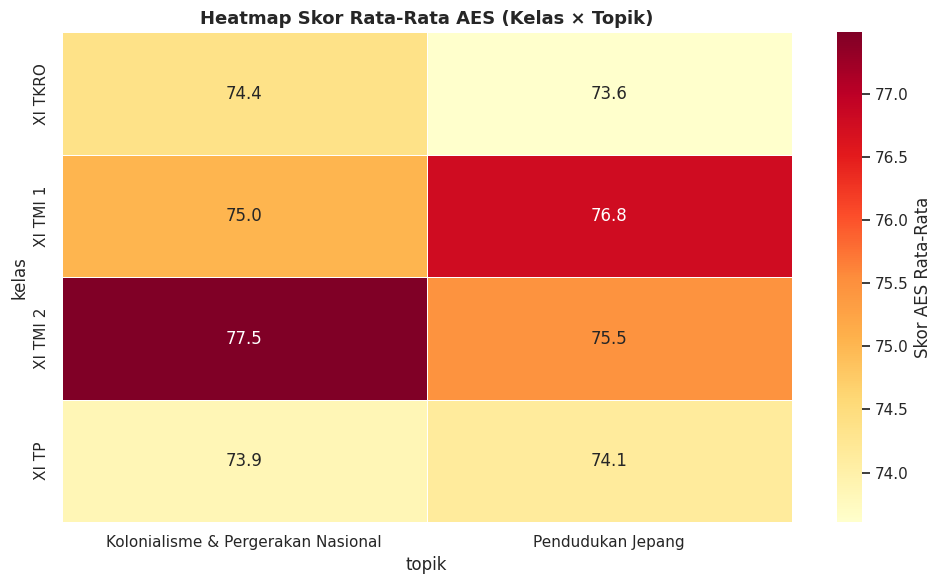

In [ ]:
pivot = df.pivot_table(values='skor_aes', index='kelas', columns='topik', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Skor AES Rata-Rata'}, ax=ax)
ax.set_title('Heatmap Skor Rata-Rata AES (Kelas × Topik)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_skor.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Analisis Kualitatif

In [ ]:
for label, ascending in [('TERTINGGI', False), ('TERENDAH', True)]:
    print('=' * 70)
    print(f'TOP 5 JAWABAN DENGAN SKOR {label} (per topik)')
    print('=' * 70)
    for topik in df['topik'].unique():
        sub = df[df['topik'] == topik].sort_values('skor_aes', ascending=ascending).head(5)
        print(f'\nTopik: {topik}')
        for _, row in sub.iterrows():
            print(f'  {row["nama"]} | Kelas {row["kelas"]} | Soal #{row["id_pertanyaan"]}')
            print(f'  Skor: {row["skor_aes"]:.2f} | {row["kategori"]}')
            print()

TOP 5 JAWABAN DENGAN SKOR TERTINGGI (per topik)

Topik: Kolonialisme & Pergerakan Nasional
  Adelia Nuraeni Putri | Kelas XI TMI 2 | Soal #3
  Skor: 92.73 | Sangat Sesuai

  Ali Nur Rahmat | Kelas XI TMI 1 | Soal #3
  Skor: 92.59 | Sangat Sesuai

  Muhamad Sudes | Kelas XI TP | Soal #3
  Skor: 92.34 | Sangat Sesuai

  Handika Meslandri S | Kelas XI TMI 2 | Soal #3
  Skor: 92.34 | Sangat Sesuai

  Muhamad Bagus Sadeli | Kelas XI TKRO | Soal #3
  Skor: 92.34 | Sangat Sesuai


Topik: Pendudukan Jepang
  Sri Utari | Kelas XI TKRO | Soal #3
  Skor: 96.32 | Sangat Sesuai

  Lanang Renaldi | Kelas XI TKRO | Soal #3
  Skor: 96.24 | Sangat Sesuai

  Cahaya Sukma | Kelas XI TKRO | Soal #3
  Skor: 94.37 | Sangat Sesuai

  Kyky Febtihkal Saputra | Kelas XI TKRO | Soal #3
  Skor: 94.37 | Sangat Sesuai

  Peby Cahya N | Kelas XI TMI 2 | Soal #3
  Skor: 93.72 | Sangat Sesuai

TOP 5 JAWABAN DENGAN SKOR TERENDAH (per topik)

Topik: Kolonialisme & Pergerakan Nasional
  Reza Lesmana | Kelas XI TMI 2 | So

In [ ]:
ringkasan_soal = df.groupby(['topik', 'id_pertanyaan']).agg(
    pertanyaan      = ('pertanyaan', 'first'),
    mean_skor       = ('skor_aes', 'mean'),
    std_skor        = ('skor_aes', 'std'),
    min_skor        = ('skor_aes', 'min'),
    max_skor        = ('skor_aes', 'max'),
    n_siswa         = ('skor_aes', 'count'),
    n_sangat_sesuai = ('kategori', lambda x: (x == 'Sangat Sesuai').sum()),
    n_cukup_sesuai  = ('kategori', lambda x: (x == 'Cukup Sesuai').sum()),
    n_kurang_sesuai = ('kategori', lambda x: (x == 'Kurang Sesuai').sum()),
    n_tidak_sesuai  = ('kategori', lambda x: (x == 'Tidak Sesuai').sum()),
).reset_index()

for _, row in ringkasan_soal.iterrows():
    print(f'[{row["topik"]}] Soal #{row["id_pertanyaan"]}')
    print(f'  Mean: {row["mean_skor"]:.2f} | Std: {row["std_skor"]:.2f} | Min: {row["min_skor"]:.2f} | Max: {row["max_skor"]:.2f}')
    print(f'  n={row["n_siswa"]} | Sangat:{row["n_sangat_sesuai"]} | Cukup:{row["n_cukup_sesuai"]} | Kurang:{row["n_kurang_sesuai"]} | Tidak:{row["n_tidak_sesuai"]}')

[Kolonialisme & Pergerakan Nasional] Soal #1
  Mean: 80.54 | Std: 5.77 | Min: 60.41 | Max: 89.46
  n=112 | Sangat:78 | Cukup:34 | Kurang:0 | Tidak:0
[Kolonialisme & Pergerakan Nasional] Soal #2
  Mean: 67.11 | Std: 9.20 | Min: 35.45 | Max: 84.63
  n=112 | Sangat:8 | Cukup:87 | Kurang:16 | Tidak:1
[Kolonialisme & Pergerakan Nasional] Soal #3
  Mean: 84.01 | Std: 9.37 | Min: 46.28 | Max: 92.73
  n=112 | Sangat:87 | Cukup:20 | Kurang:5 | Tidak:0
[Kolonialisme & Pergerakan Nasional] Soal #4
  Mean: 72.24 | Std: 6.18 | Min: 51.06 | Max: 84.89
  n=112 | Sangat:8 | Cukup:103 | Kurang:1 | Tidak:0
[Kolonialisme & Pergerakan Nasional] Soal #5
  Mean: 73.04 | Std: 11.39 | Min: 37.05 | Max: 88.74
  n=112 | Sangat:36 | Cukup:61 | Kurang:13 | Tidak:2
[Pendudukan Jepang] Soal #1
  Mean: 71.50 | Std: 8.54 | Min: 36.26 | Max: 83.36
  n=123 | Sangat:12 | Cukup:95 | Kurang:15 | Tidak:1
[Pendudukan Jepang] Soal #2
  Mean: 74.14 | Std: 11.78 | Min: 27.55 | Max: 93.61
  n=123 | Sangat:40 | Cukup:73 | Kurang

## 11. Rekap Skor per Siswa

In [ ]:
rekap_siswa = df.groupby(['nama', 'kelas']).agg(
    jumlah_soal = ('skor_aes', 'count'),
    rata_skor   = ('skor_aes', 'mean'),
    total_skor  = ('skor_aes', 'sum'),
    skor_min    = ('skor_aes', 'min'),
    skor_max    = ('skor_aes', 'max'),
).reset_index().sort_values('rata_skor', ascending=False)

rekap_siswa['rata_skor']  = rekap_siswa['rata_skor'].round(2)
rekap_siswa['total_skor'] = rekap_siswa['total_skor'].round(2)
print(rekap_siswa.to_string(index=False))

                    nama    kelas  jumlah_soal  rata_skor  total_skor  skor_min  skor_max
          Lanang Renaldi  XI TKRO            5    83.7500    418.7300   73.9800   96.2400
     Rafhael Reza Putra     XI TP           10    83.5600    835.6100   66.0000   91.8900
           Dede Hidayat  XI TMI 2           10    83.1000    830.9700   73.9700   93.6900
        Adelia Ramadhani XI TMI 1           10    82.8300    828.3000   71.5700   93.5100
           Rizki Maulana XI TMI 1           10    82.3900    823.9100   71.2600   93.6100
    Rezqi Aditya Nugroho  XI TKRO           10    82.0500    820.5000   60.9400   91.7300
  Hafidz Isna Hibatullah XI TMI 2           10    81.8800    818.8100   66.2600   91.2100
            Cahaya Sukma  XI TKRO            5    81.7600    408.8200   69.0700   94.3700
               Sri Utari  XI TKRO            5    81.5800    407.9000   68.5100   96.3200
    Diegi Hadi Septian R XI TMI 2           10    81.5200    815.2200   66.0200   92.7500
  Kyky Feb

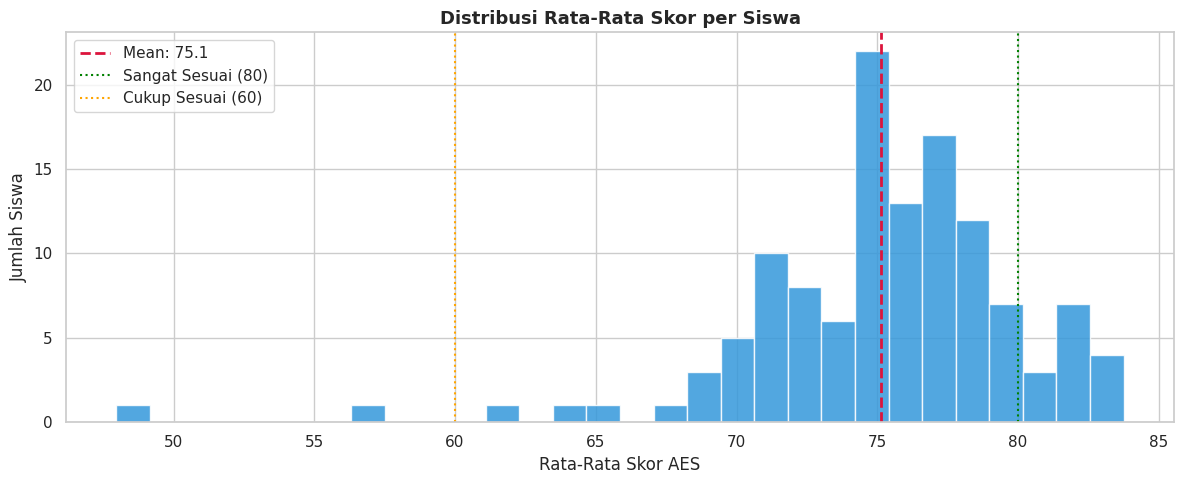

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(rekap_siswa['rata_skor'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(rekap_siswa['rata_skor'].mean(), color='crimson', linestyle='--', linewidth=2,
           label=f'Mean: {rekap_siswa["rata_skor"].mean():.1f}')
ax.axvline(THRESHOLD_TINGGI, color='green',  linestyle=':', linewidth=1.5, label=f'Sangat Sesuai ({THRESHOLD_TINGGI})')
ax.axvline(THRESHOLD_SEDANG, color='orange', linestyle=':', linewidth=1.5, label=f'Cukup Sesuai ({THRESHOLD_SEDANG})')
ax.set_title('Distribusi Rata-Rata Skor per Siswa', fontsize=13, fontweight='bold')
ax.set_xlabel('Rata-Rata Skor AES')
ax.set_ylabel('Jumlah Siswa')
ax.legend()
plt.tight_layout()
plt.savefig('distribusi_skor_siswa.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Inference — Penilaian Jawaban Baru

In [ ]:
kunci_unik = df.groupby(['topik', 'id_pertanyaan']).agg(
    pertanyaan    = ('pertanyaan', 'first'),
    kunci_jawaban = ('kunci_jawaban', 'first'),
    kunci_bersih  = ('kunci_jawaban_bersih', 'first'),
).reset_index()

embeddings_kunci_unik = get_indobert_embeddings(
    kunci_unik['kunci_bersih'].tolist(), tokenizer, model_indobert, DEVICE)
kunci_unik = kunci_unik.copy()
kunci_unik['embedding_kunci'] = list(embeddings_kunci_unik)
print(f'{len(kunci_unik)} kunci jawaban unik siap.')

Encoding (mean_pooling):   0%|          | 0/1 [00:00<?, ?batch/s]

10 kunci jawaban unik siap.


In [ ]:
def nilai_jawaban_baru(jawaban_baru, topik, id_pertanyaan, kunci_unik_df,
                        tokenizer, model, device, verbose=True):
    kunci_row = kunci_unik_df[
        (kunci_unik_df['topik'] == topik) &
        (kunci_unik_df['id_pertanyaan'] == id_pertanyaan)
    ]
    if len(kunci_row) == 0:
        raise ValueError(f'Kombinasi topik/soal tidak ditemukan.')
    kunci_row = kunci_row.iloc[0]

    jawaban_bersih = preprocessor.clean(jawaban_baru)
    if not jawaban_bersih:
        return {'skor': 0.0, 'cosine_similarity': 0.0, 'kategori': 'Tidak Sesuai'}

    with torch.no_grad():
        encoded = tokenizer([jawaban_bersih], padding=True, truncation=True,
                            max_length=MAX_LENGTH, return_tensors='pt')
        input_ids      = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        token_type_ids = encoded.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                        token_type_ids=token_type_ids)

        if EMBEDDING_STRATEGY == 'cls':
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        else:
            token_emb = outputs.last_hidden_state
            mask_exp  = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
            emb = (torch.sum(token_emb * mask_exp, dim=1) /
                   torch.clamp(mask_exp.sum(dim=1), min=1e-9)).cpu().numpy()

    sim      = float(np.clip(cosine_similarity(emb, np.array(kunci_row['embedding_kunci']).reshape(1, -1))[0][0], 0, 1))
    skor     = round(sim * 100, 2)
    kategori = kategorikan_skor(skor)

    if verbose:
        print(f'Cosine Sim : {sim:.6f}')
        print(f'Skor AES   : {skor:.2f} / 100')
        print(f'Kategori   : {kategori}')

    return {'topik': topik, 'id_pertanyaan': id_pertanyaan,
            'cosine_similarity': round(sim, 6), 'skor_aes': skor, 'kategori': kategori}

In [ ]:
jawaban_contoh_1 = """
Kolonialisme adalah sistem di mana suatu negara yang lebih kuat menguasai
wilayah bangsa lain dengan tujuan mengeksploitasi sumber daya alam, tenaga kerja,
dan ekonomi wilayah tersebut untuk kepentingan negara penjajah.
"""
nilai_jawaban_baru(jawaban_contoh_1, 'Kolonialisme & Pergerakan Nasional', 1,
                    kunci_unik, tokenizer, model_indobert, DEVICE)


Cosine Sim : 0.860012
Skor AES   : 86.00 / 100
Kategori   : Sangat Sesuai


{'topik': 'Kolonialisme & Pergerakan Nasional',
 'id_pertanyaan': 1,
 'cosine_similarity': 0.860012,
 'skor_aes': 86.0,
 'kategori': 'Sangat Sesuai'}

In [ ]:
nilai_jawaban_baru('Jepang butuh minyak bumi untuk perang.',
                    'Pendudukan Jepang', 1,
                    kunci_unik, tokenizer, model_indobert, DEVICE)

Cosine Sim : 0.624172
Skor AES   : 62.42 / 100
Kategori   : Cukup Sesuai


{'topik': 'Pendudukan Jepang',
 'id_pertanyaan': 1,
 'cosine_similarity': 0.624172,
 'skor_aes': 62.42,
 'kategori': 'Cukup Sesuai'}

In [ ]:
jawaban_contoh_3 = """
Jepang melakukan propaganda dengan membentuk Gerakan 3A yaitu Jepang Cahaya Asia,
Jepang Pelindung Asia, dan Jepang Pemimpin Asia. Selain itu Jepang juga mengaku
sebagai saudara tua bangsa Indonesia.
"""
nilai_jawaban_baru(jawaban_contoh_3, 'Pendudukan Jepang', 2,
                    kunci_unik, tokenizer, model_indobert, DEVICE)

Cosine Sim : 0.737751
Skor AES   : 73.78 / 100
Kategori   : Cukup Sesuai


{'topik': 'Pendudukan Jepang',
 'id_pertanyaan': 2,
 'cosine_similarity': 0.737751,
 'skor_aes': 73.78,
 'kategori': 'Cukup Sesuai'}

## 13. Evaluasi Sistem AES

| Kelompok | Fokus Evaluasi |
|:---|:---|
| **Kelompok 1** | Embedding Quality |
| **Kelompok 2** | Scoring Consistency |
| **Kelompok 3** | Perbandingan Model |
| **Kelompok 4** | Validasi Eksternal (vs Skor Guru) |

### 13.1 Kelompok 1 — Embedding Quality

In [ ]:
hasil_embedding_quality = {}

intra_scores = {}
for topik in df['topik'].unique():
    for qid in sorted(df['id_pertanyaan'].unique()):
        key  = f'{topik[:12].strip()}|Q{qid}'
        mask = (df['topik'] == topik) & (df['id_pertanyaan'] == qid)
        embs = embeddings_siswa[mask]
        if len(embs) < 2:
            continue
        sim_matrix = cos_sim_matrix(embs)
        n = len(embs)
        upper_vals = sim_matrix[np.triu_indices(n, k=1)]
        intra_scores[key] = {'mean': float(upper_vals.mean()), 'std': float(upper_vals.std()),
                              'n_pairs': len(upper_vals), 'topik': topik, 'qid': qid}

inter_scores = {}
topik_list = df['topik'].unique()
for t1, t2 in combinations(topik_list, 2):
    key    = f'{t1[:10].strip()} vs {t2[:10].strip()}'
    embs1  = embeddings_siswa[df['topik'] == t1]
    embs2  = embeddings_siswa[df['topik'] == t2]
    n_samp = min(100, len(embs1), len(embs2))
    idx1   = np.random.choice(len(embs1), n_samp, replace=False)
    idx2   = np.random.choice(len(embs2), n_samp, replace=False)
    cross  = cos_sim_matrix(embs1[idx1], embs2[idx2])
    inter_scores[key] = {'mean': float(cross.mean()), 'std': float(cross.std())}

all_intra = [v['mean'] for v in intra_scores.values()]
all_inter = [v['mean'] for v in inter_scores.values()]
mean_intra = np.mean(all_intra)
mean_inter = np.mean(all_inter) if all_inter else 0
gap = mean_intra - mean_inter

print(f'Rata-rata Intra-class : {mean_intra:.4f}')
print(f'Rata-rata Inter-class : {mean_inter:.4f}')
print(f'Discriminative Gap    : {gap:.4f}  {"✅" if gap > 0 else "⚠️"}')

hasil_embedding_quality.update({
    'intra_class_mean'  : round(mean_intra, 4),
    'inter_class_mean'  : round(mean_inter, 4),
    'discriminative_gap': round(gap, 4),
})

Rata-rata Intra-class : 0.7319
Rata-rata Inter-class : 0.5092
Discriminative Gap    : 0.2227  ✅


In [ ]:
cohesion_data = []
for topik in df['topik'].unique():
    for qid in sorted(df['id_pertanyaan'].unique()):
        mask = (df['topik'] == topik) & (df['id_pertanyaan'] == qid)
        embs = embeddings_siswa[mask]
        if len(embs) < 2:
            continue
        centroid = embs.mean(axis=0, keepdims=True)
        sim_to_c = cos_sim_matrix(embs, centroid).flatten()
        cohesion_data.append({
            'topik': topik, 'soal': f'Soal {qid}', 'qid': qid,
            'cohesion_mean': float(sim_to_c.mean()),
            'cohesion_std' : float(sim_to_c.std()),
            'n': int(embs.shape[0])
        })

df_cohesion = pd.DataFrame(cohesion_data)
mean_cohesion = df_cohesion['cohesion_mean'].mean()
print(f'Rata-rata cohesion: {mean_cohesion:.4f}')
for _, row in df_cohesion.iterrows():
    print(f'  [{row["topik"][:14]:<14}] {row["soal"]} : {row["cohesion_mean"]:.4f} ±{row["cohesion_std"]:.4f}')
hasil_embedding_quality['mean_cohesion'] = round(mean_cohesion, 4)

Rata-rata cohesion: 0.8562
  [Kolonialisme &] Soal 1 : 0.9032 ±0.0465
  [Kolonialisme &] Soal 2 : 0.8118 ±0.0746
  [Kolonialisme &] Soal 3 : 0.8961 ±0.0837
  [Kolonialisme &] Soal 4 : 0.8683 ±0.0548
  [Kolonialisme &] Soal 5 : 0.8376 ±0.0845
  [Pendudukan Jep] Soal 1 : 0.8429 ±0.0659
  [Pendudukan Jep] Soal 2 : 0.8366 ±0.0886
  [Pendudukan Jep] Soal 3 : 0.8893 ±0.0673
  [Pendudukan Jep] Soal 4 : 0.8490 ±0.0692
  [Pendudukan Jep] Soal 5 : 0.8274 ±0.0597


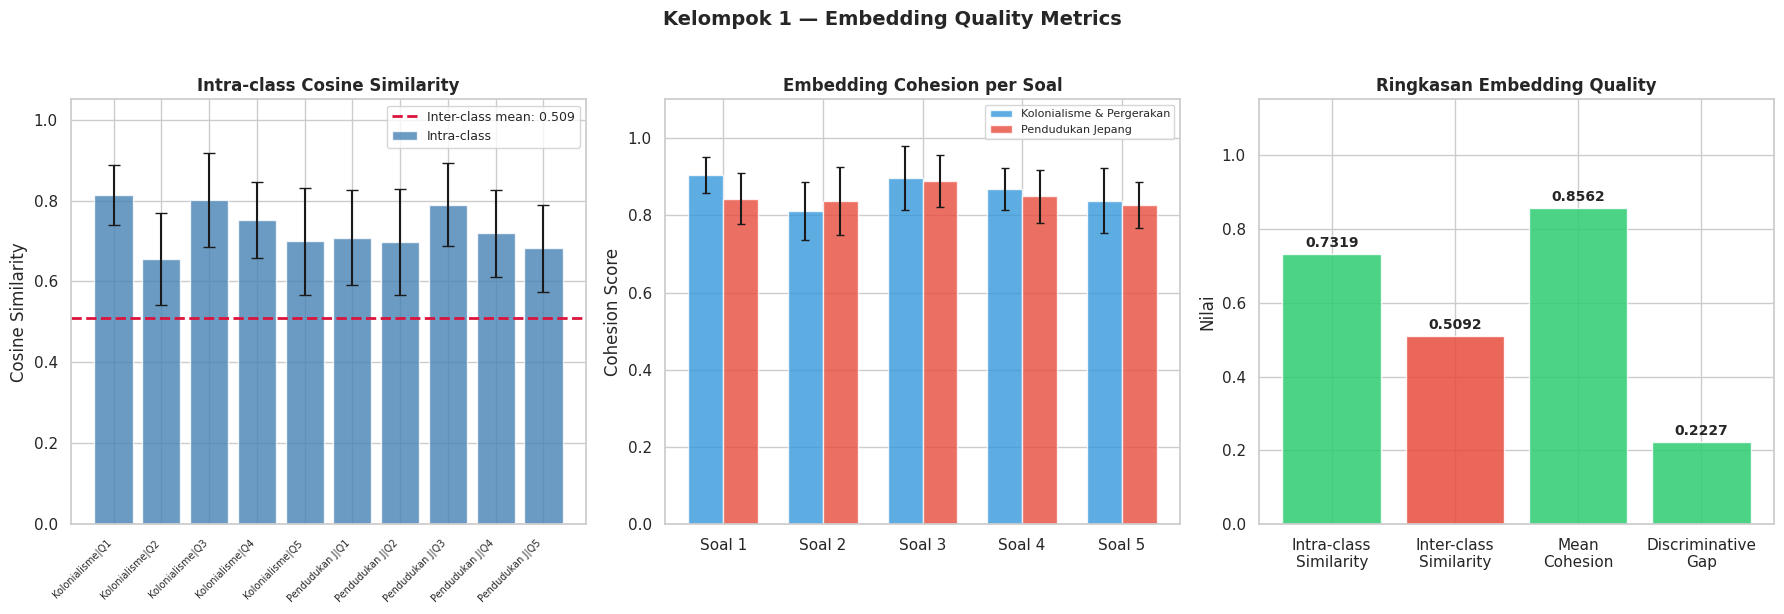

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

labels_intra = list(intra_scores.keys())
vals_intra   = [v['mean'] for v in intra_scores.values()]
stds_intra   = [v['std']  for v in intra_scores.values()]
x = np.arange(len(labels_intra))
axes[0].bar(x, vals_intra, yerr=stds_intra, capsize=4,
            color='steelblue', alpha=0.8, edgecolor='white', label='Intra-class')
if all_inter:
    axes[0].axhline(mean_inter, color='crimson', linestyle='--', linewidth=2,
                    label=f'Inter-class mean: {mean_inter:.3f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_intra, rotation=45, ha='right', fontsize=7)
axes[0].set_title('Intra-class Cosine Similarity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cosine Similarity')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

soal_ids    = sorted(df_cohesion['qid'].unique())
topik_uniq  = df_cohesion['topik'].unique()
warna_topik = ['#3498db', '#e74c3c']
width = 0.35
x2 = np.arange(len(soal_ids))
for i, (topik, warna) in enumerate(zip(topik_uniq, warna_topik)):
    sub = df_cohesion[df_cohesion['topik'] == topik].sort_values('qid')
    axes[1].bar(x2 + i * width, sub['cohesion_mean'], width,
                yerr=sub['cohesion_std'], capsize=3,
                label=topik[:25], color=warna, alpha=0.8, edgecolor='white')
axes[1].set_xticks(x2 + width / 2)
axes[1].set_xticklabels([f'Soal {q}' for q in soal_ids])
axes[1].set_title('Embedding Cohesion per Soal', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cohesion Score')
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=8)

metrics_summary = {
    'Intra-class\nSimilarity': mean_intra,
    'Inter-class\nSimilarity': mean_inter,
    'Mean\nCohesion'         : mean_cohesion,
    'Discriminative\nGap'    : max(gap, 0)
}
warna_bar = ['#2ecc71' if k != 'Inter-class\nSimilarity' else '#e74c3c'
             for k in metrics_summary]
bars3 = axes[2].bar(metrics_summary.keys(), metrics_summary.values(),
                    color=warna_bar, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, metrics_summary.values()):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01, f'{val:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[2].set_title('Ringkasan Embedding Quality', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Nilai')
axes[2].set_ylim(0, 1.15)

plt.suptitle('Kelompok 1 — Embedding Quality Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_embedding_quality.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.2 Kelompok 2 — Scoring Consistency

In [ ]:
thresholds_to_test = [(80, 60, 40), (75, 50, 25), (70, 50, 30), (65, 45, 25)]
sensitivity_data = []
n_total = len(df)

for t_t, t_s, t_r in thresholds_to_test:
    n_sangat = (df['skor_aes'] >= t_t).sum()
    n_cukup  = ((df['skor_aes'] >= t_s) & (df['skor_aes'] < t_t)).sum()
    n_kurang = ((df['skor_aes'] >= t_r) & (df['skor_aes'] < t_s)).sum()
    n_tidak  = (df['skor_aes'] < t_r).sum()
    sensitivity_data.append({
        'threshold'         : f'T={t_t}/{t_s}/{t_r}',
        'T_tinggi'          : t_t, 'T_sedang': t_s, 'T_rendah': t_r,
        'Sangat Sesuai (%)' : round(n_sangat / n_total * 100, 1),
        'Cukup Sesuai (%)'  : round(n_cukup  / n_total * 100, 1),
        'Kurang Sesuai (%)' : round(n_kurang  / n_total * 100, 1),
        'Tidak Sesuai (%)'  : round(n_tidak   / n_total * 100, 1),
    })

df_sensitivity = pd.DataFrame(sensitivity_data)
print(df_sensitivity.to_string(index=False))
print(f'\nThreshold aktif: {THRESHOLD_TINGGI}/{THRESHOLD_SEDANG}/{THRESHOLD_RENDAH}')

 threshold  T_tinggi  T_sedang  T_rendah  Sangat Sesuai (%)  Cukup Sesuai (%)  Kurang Sesuai (%)  Tidak Sesuai (%)
T=80/60/40        80        60        40            35.9000           56.3000             7.1000            0.7000
T=75/50/25        75        50        25            56.5000           41.0000             2.5000            0.0000
T=70/50/30        70        50        30            72.3000           25.2000             2.3000            0.2000
T=65/45/25        65        45        25            83.0000           15.9000             1.1000            0.0000

Threshold aktif: 80/60/40


In [ ]:
hasil_cronbach = {}
for topik in df['topik'].unique():
    pivot_cr = df[df['topik'] == topik].pivot_table(
        index='nama', columns='id_pertanyaan', values='skor_aes')
    if not pivot_cr.empty and pivot_cr.shape[1] > 1:
        alpha, _ = pg.cronbach_alpha(data=pivot_cr, items=pivot_cr.columns) # Discard the second value, as it seems to be another alpha value
        # Use pivot_cr.shape[1] as the actual number of items
        num_items = pivot_cr.shape[1]
        hasil_cronbach[topik] = float(alpha)
        status = '✅ Acceptable' if alpha >= 0.70 else '⚠️  Needs review'
        print(f'  [{topik[:18]:<18}] α={alpha:.4f} (n={int(num_items)} soal) {status}')
    else:
        hasil_cronbach[topik] = float('nan')
        print(f'  [{topik[:18]:<18}] Data tidak cukup.')

  [Kolonialisme & Per] α=0.5580 (n=5 soal) ⚠️  Needs review
  [Pendudukan Jepang ] α=0.6564 (n=5 soal) ⚠️  Needs review


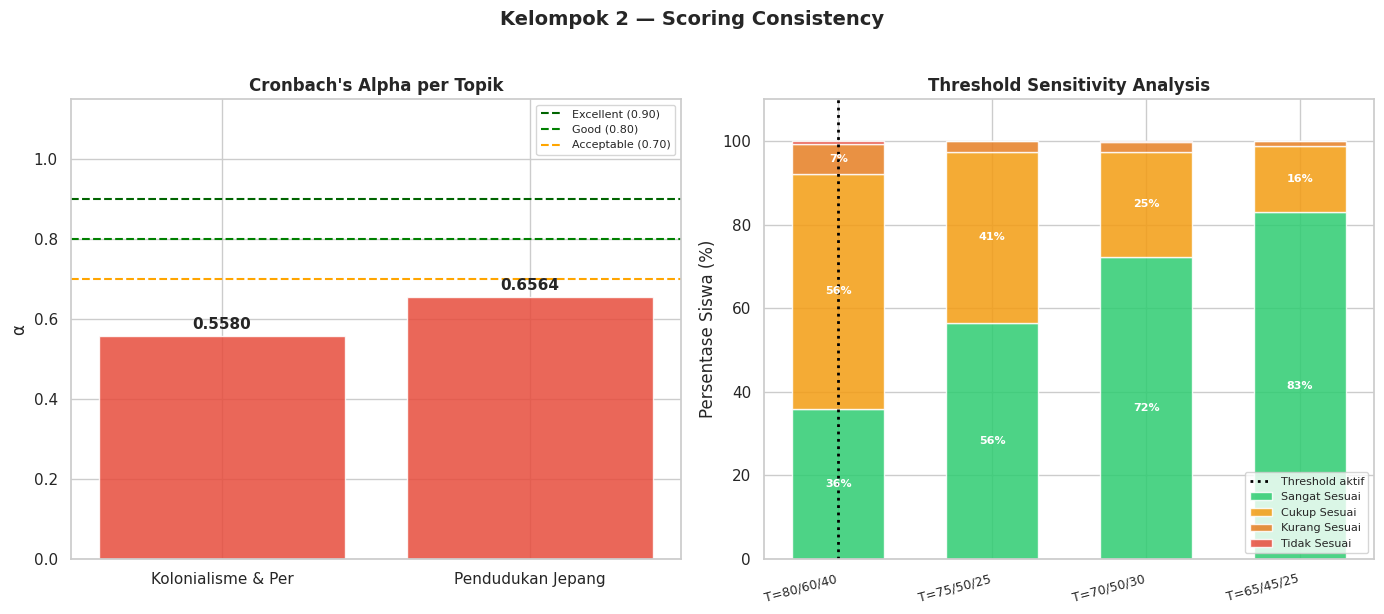

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

alpha_vals  = list(hasil_cronbach.values())
topik_lbls  = [t[:18] for t in hasil_cronbach.keys()]
warna_alpha = ['#2ecc71' if v >= 0.70 else '#e74c3c' for v in alpha_vals]
bars1 = axes[0].bar(topik_lbls, alpha_vals, color=warna_alpha, alpha=0.85, edgecolor='white')
axes[0].axhline(0.90, color='darkgreen', linestyle='--', linewidth=1.5, label='Excellent (0.90)')
axes[0].axhline(0.80, color='green',     linestyle='--', linewidth=1.5, label='Good (0.80)')
axes[0].axhline(0.70, color='orange',    linestyle='--', linewidth=1.5, label='Acceptable (0.70)')
for bar, val in zip(bars1, alpha_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title("Cronbach's Alpha per Topik", fontsize=12, fontweight='bold')
axes[0].set_ylabel("α")
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=8)

x3     = np.arange(len(df_sensitivity))
width3 = 0.6
cols   = ['Sangat Sesuai (%)', 'Cukup Sesuai (%)', 'Kurang Sesuai (%)', 'Tidak Sesuai (%)']
warna3 = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bottom = np.zeros(len(df_sensitivity))
for col, warna in zip(cols, warna3):
    vals = df_sensitivity[col].values
    axes[1].bar(x3, vals, width3, bottom=bottom, label=col.replace(' (%)', ''),
                color=warna, alpha=0.85, edgecolor='white')
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            axes[1].text(xi, b + v / 2, f'{v:.0f}%',
                         ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    bottom += vals
idx_aktif = next(i for i, row in df_sensitivity.iterrows()
                  if row['T_tinggi'] == THRESHOLD_TINGGI and row['T_sedang'] == THRESHOLD_SEDANG)
axes[1].set_xticks(x3)
axes[1].set_xticklabels(df_sensitivity['threshold'], rotation=15, ha='right', fontsize=9)
axes[1].axvline(idx_aktif, color='black', linestyle=':', linewidth=2, label='Threshold aktif')
axes[1].set_title('Threshold Sensitivity Analysis', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Persentase Siswa (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=8)

plt.suptitle('Kelompok 2 — Scoring Consistency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_scoring_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.3 Kelompok 3 — Perbandingan Model

| Model | Mekanisme Skoring |
|:---|:---|
| **A — IndoBERT Saja** | `skor = 1 / (1 + euclidean_distance) × 100` |
| **B — IndoBERT + Cosine Similarity** | `skor = cosine_similarity × 100` |

In [ ]:
euclidean_dist_raw = np.linalg.norm(embeddings_siswa - embeddings_kunci, axis=1)
euclidean_sim      = 1 / (1 + euclidean_dist_raw)
skor_model_a       = (euclidean_sim * 100).round(2)

df['euclidean_distance']         = euclidean_dist_raw.round(6)
df['skor_model_a_indobert_saja'] = skor_model_a
df['kategori_model_a']           = df['skor_model_a_indobert_saja'].apply(kategorikan_skor)

print('Model A (IndoBERT Saja — Euclidean):')
print(f'  Skor -> Min:{skor_model_a.min():.2f} Max:{skor_model_a.max():.2f} Mean:{skor_model_a.mean():.2f} Std:{skor_model_a.std():.2f}')
print('\nModel B (IndoBERT + Cosine Sim):')
print(f'  Skor -> Min:{df["skor_aes"].min():.2f} Max:{df["skor_aes"].max():.2f} Mean:{df["skor_aes"].mean():.2f} Std:{df["skor_aes"].std():.2f}')

Model A (IndoBERT Saja — Euclidean):
  Skor -> Min:3.55 Max:18.61 Mean:8.49 Std:2.01

Model B (IndoBERT + Cosine Sim):
  Skor -> Min:27.55 Max:96.32 Mean:75.20 Std:10.67


In [ ]:
r_all,   _ = stats.pearsonr(df['panjang_jawaban_siswa'], df['skor_aes'])
r_all_a, _ = stats.pearsonr(df['panjang_jawaban_siswa'], df['skor_model_a_indobert_saja'])

bias_b = '✅ Tidak bias' if abs(r_all)   < 0.40 else '⚠️ Potensi bias'
bias_a = '✅ Tidak bias' if abs(r_all_a) < 0.40 else '⚠️ Potensi bias'
print(f'Korelasi Skor vs Panjang Teks:')
print(f'  Model A : r = {r_all_a:.4f}  {bias_a}')
print(f'  Model B : r = {r_all:.4f}   {bias_b}')

hasil_embedding_quality['korelasi_skor_panjang_r']         = round(r_all, 4)
hasil_embedding_quality['korelasi_skor_panjang_r_model_a'] = round(r_all_a, 4)

Korelasi Skor vs Panjang Teks:
  Model A : r = 0.7241  ⚠️ Potensi bias
  Model B : r = 0.6435   ⚠️ Potensi bias


In [ ]:
r_ab_pearson,  _ = stats.pearsonr(df['skor_model_a_indobert_saja'], df['skor_aes'])
r_ab_spearman, _ = stats.spearmanr(df['skor_model_a_indobert_saja'], df['skor_aes'])

kategori_order = ['Tidak Sesuai', 'Kurang Sesuai', 'Cukup Sesuai', 'Sangat Sesuai']
kappa_ab = cohen_kappa_score(df['kategori'], df['kategori_model_a'], labels=kategori_order)
agreement_ab = (df['kategori_model_a'] == df['kategori']).mean()

print(f'Korelasi Skor A vs B  -> Pearson r={r_ab_pearson:.4f} | Spearman r={r_ab_spearman:.4f}')
print(f'Kesesuaian kategori   : {agreement_ab*100:.1f}%')
print(f"Cohen's Kappa         : {kappa_ab:.4f}")

cm_ab = pd.crosstab(df['kategori'], df['kategori_model_a'],
                     rownames=['Model B (Cosine)'], colnames=['Model A (IndoBERT)'])
print('\nConfusion Matrix:')
print(cm_ab)

hasil_embedding_quality['pearson_model_a_vs_b']     = round(r_ab_pearson, 4)
hasil_embedding_quality['cohen_kappa_model_a_vs_b'] = round(kappa_ab, 4)

Korelasi Skor A vs B  -> Pearson r=0.9022 | Spearman r=0.9681
Kesesuaian kategori   : 0.7%
Cohen's Kappa         : 0.0000

Confusion Matrix:
Model A (IndoBERT)  Tidak Sesuai
Model B (Cosine)                
Cukup Sesuai                 661
Kurang Sesuai                 84
Sangat Sesuai                422
Tidak Sesuai                   8


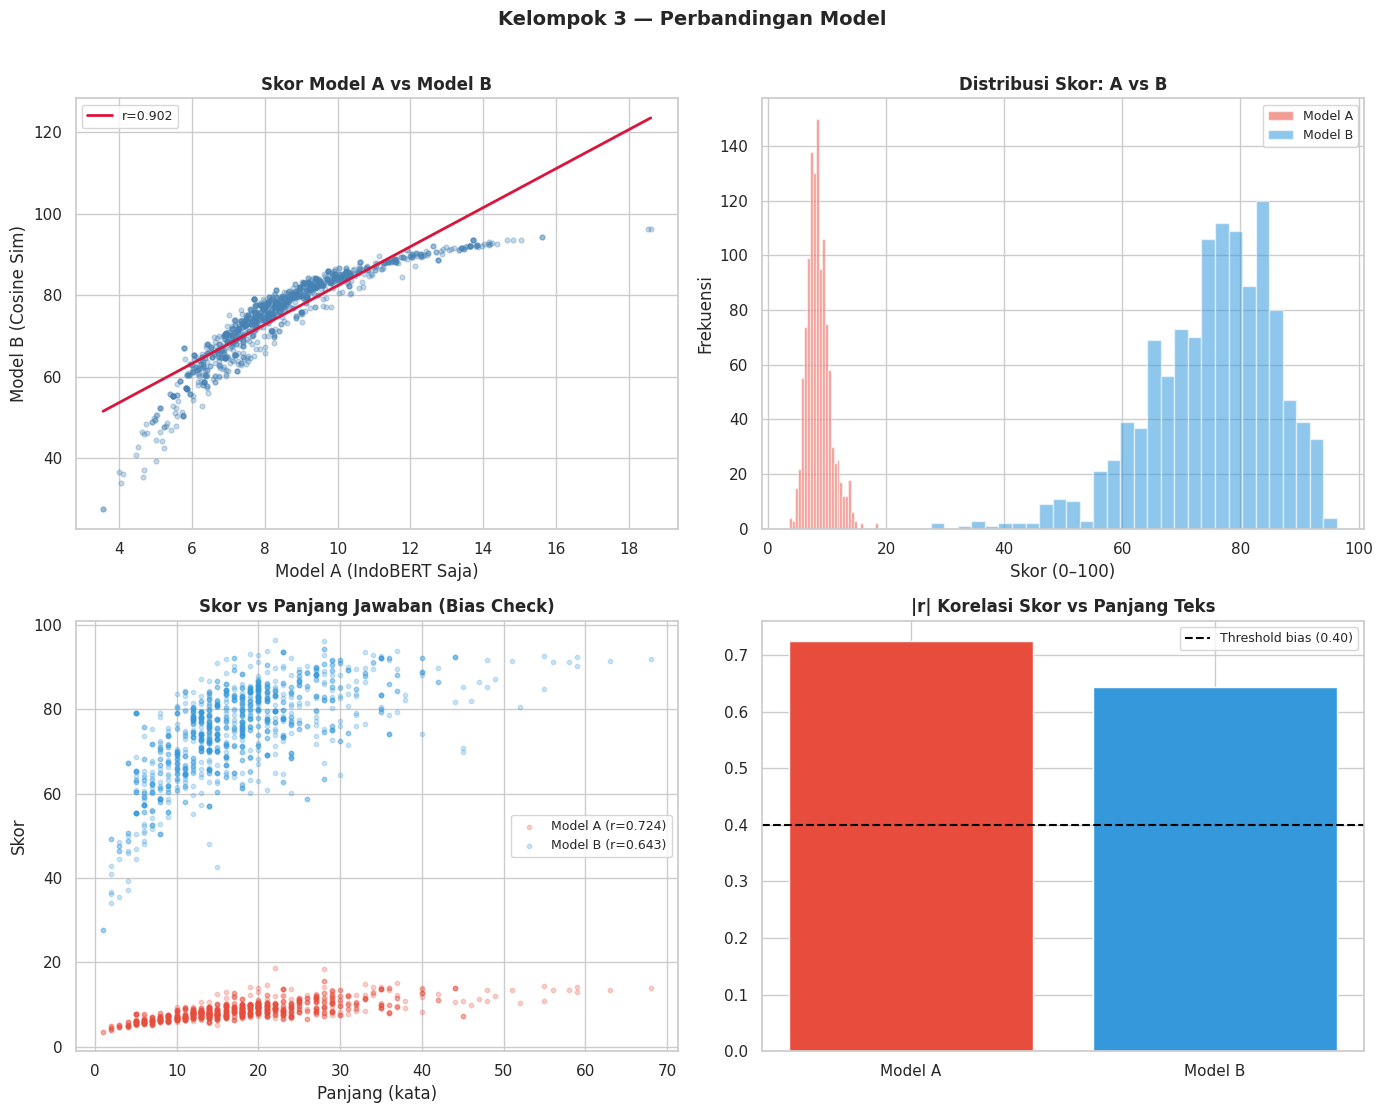

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].scatter(df['skor_model_a_indobert_saja'], df['skor_aes'], alpha=0.3, s=12, color='steelblue')
m_ab, b_ab = np.polyfit(df['skor_model_a_indobert_saja'], df['skor_aes'], 1)
x_ab = np.linspace(df['skor_model_a_indobert_saja'].min(), df['skor_model_a_indobert_saja'].max(), 100)
axes[0, 0].plot(x_ab, m_ab * x_ab + b_ab, color='crimson', linewidth=2, label=f'r={r_ab_pearson:.3f}')
axes[0, 0].set_title('Skor Model A vs Model B', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Model A (IndoBERT Saja)')
axes[0, 0].set_ylabel('Model B (Cosine Sim)')
axes[0, 0].legend(fontsize=9)

axes[0, 1].hist(df['skor_model_a_indobert_saja'], bins=30, alpha=0.55, label='Model A', color='#e74c3c', edgecolor='white')
axes[0, 1].hist(df['skor_aes'], bins=30, alpha=0.55, label='Model B', color='#3498db', edgecolor='white')
axes[0, 1].set_title('Distribusi Skor: A vs B', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Skor (0–100)')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].legend(fontsize=9)

axes[1, 0].scatter(df['panjang_jawaban_siswa'], df['skor_model_a_indobert_saja'],
                    alpha=0.25, s=10, color='#e74c3c', label=f'Model A (r={r_all_a:.3f})')
axes[1, 0].scatter(df['panjang_jawaban_siswa'], df['skor_aes'],
                    alpha=0.25, s=10, color='#3498db', label=f'Model B (r={r_all:.3f})')
axes[1, 0].set_title('Skor vs Panjang Jawaban (Bias Check)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Panjang (kata)')
axes[1, 0].set_ylabel('Skor')
axes[1, 0].legend(fontsize=9)

if hasil_model_comparison:
    metrik = ['Pearson r\nvs Guru', "Cohen's\nKappa vs Guru"]
    vals_a = [hasil_model_comparison['model_a']['pearson_r'], hasil_model_comparison['model_a']['cohen_kappa']]
    vals_b = [hasil_model_comparison['model_b']['pearson_r'], hasil_model_comparison['model_b']['cohen_kappa']]
    x = np.arange(len(metrik))
    axes[1, 1].bar(x - 0.175, vals_a, 0.35, label='Model A', color='#e74c3c')
    axes[1, 1].bar(x + 0.175, vals_b, 0.35, label='Model B', color='#3498db')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(metrik)
    axes[1, 1].set_title('Validitas Kriteria vs Skor Guru', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=9)
else:
    axes[1, 1].bar(['Model A', 'Model B'], [abs(r_all_a), abs(r_all)], color=['#e74c3c', '#3498db'])
    axes[1, 1].axhline(0.40, color='black', linestyle='--', label='Threshold bias (0.40)')
    axes[1, 1].set_title('|r| Korelasi Skor vs Panjang Teks', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=9)

plt.suptitle('Kelompok 3 — Perbandingan Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eval_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.4 Kelompok 4 — Validasi Eksternal (vs Skor Guru)

In [ ]:
df_validasi = pd.read_excel('Dokumen Validasi Nilai Esai Sejarah_FIX.xlsx', header=1)
df_validasi.columns = [c.strip() for c in df_validasi.columns]
print(f'Sampel validasi : {len(df_validasi)}')
print(f'Siswa unik      : {df_validasi["Nama Siswa"].nunique()}')
df_validasi[['Nama Siswa', 'Topik Ujian', 'ID', 'Skor Sistem (AI)',
              'Skor Manual Guru (0-100)', 'Selisih Absolut']].head()

Sampel validasi : 40
Siswa unik      : 4


,Nama Siswa,Topik Ujian,ID,Skor Sistem (AI),Skor Manual Guru (0-100),Selisih Absolut
0,Abdurrahman M Syafik,Kolonialisme & Pergerakan Nasional,1,85,88,3
1,Abdurrahman M Syafik,Kolonialisme & Pergerakan Nasional,2,68,70,2
2,Abdurrahman M Syafik,Kolonialisme & Pergerakan Nasional,3,65,68,3
3,Abdurrahman M Syafik,Kolonialisme & Pergerakan Nasional,4,88,90,2
4,Abdurrahman M Syafik,Kolonialisme & Pergerakan Nasional,5,73,75,2


In [ ]:
skor_ai_val   = df_validasi['Skor Sistem (AI)'].values.astype(float)
skor_guru_val = df_validasi['Skor Manual Guru (0-100)'].values.astype(float)
selisih_val   = skor_ai_val - skor_guru_val

pearson_val_r,  pearson_val_p  = stats.pearsonr(skor_ai_val, skor_guru_val)
spearman_val_r, spearman_val_p = stats.spearmanr(skor_ai_val, skor_guru_val)
mae_val  = mean_absolute_error(skor_guru_val, skor_ai_val)
rmse_val = np.sqrt(mean_squared_error(skor_guru_val, skor_ai_val))
t_stat_val, t_p_val = stats.ttest_rel(skor_ai_val, skor_guru_val)

print(f'Pearson r  : {pearson_val_r:.4f}  (p={pearson_val_p:.2e})')
print(f'Spearman r : {spearman_val_r:.4f}  (p={spearman_val_p:.2e})')
print(f'MAE        : {mae_val:.2f}')
print(f'RMSE       : {rmse_val:.2f}')
print(f'Selisih    : {selisih_val.mean():+.2f} ± {selisih_val.std():.2f}')
print(f'Paired t   : t={t_stat_val:.3f}, p={t_p_val:.2e}')

Pearson r  : 0.9929  (p=8.87e-37)
Spearman r : 0.9865  (p=1.92e-31)
MAE        : 2.67
RMSE       : 2.89
Selisih    : -2.67 ± 1.08
Paired t   : t=-15.448, p=3.25e-18


In [ ]:
df_validasi['kategori_ai']   = df_validasi['Skor Sistem (AI)'].apply(kategorikan_skor)
df_validasi['kategori_guru'] = df_validasi['Skor Manual Guru (0-100)'].apply(kategorikan_skor)

agreement_val = (df_validasi['kategori_ai'] == df_validasi['kategori_guru']).mean()
kappa_val     = cohen_kappa_score(df_validasi['kategori_guru'], df_validasi['kategori_ai'],
                                   labels=kategori_order)
print(f'Kesesuaian kategori : {agreement_val*100:.1f}%')
print(f"Cohen's Kappa       : {kappa_val:.4f}")

cm_val = pd.crosstab(df_validasi['kategori_guru'], df_validasi['kategori_ai'],
                      rownames=['Guru'], colnames=['Sistem (AI)'])
print('\nConfusion Matrix:')
print(cm_val)

Kesesuaian kategori : 92.5%
Cohen's Kappa       : 0.8507

Confusion Matrix:
Sistem (AI)    Cukup Sesuai  Sangat Sesuai
Guru                                      
Cukup Sesuai             18              0
Sangat Sesuai             3             19


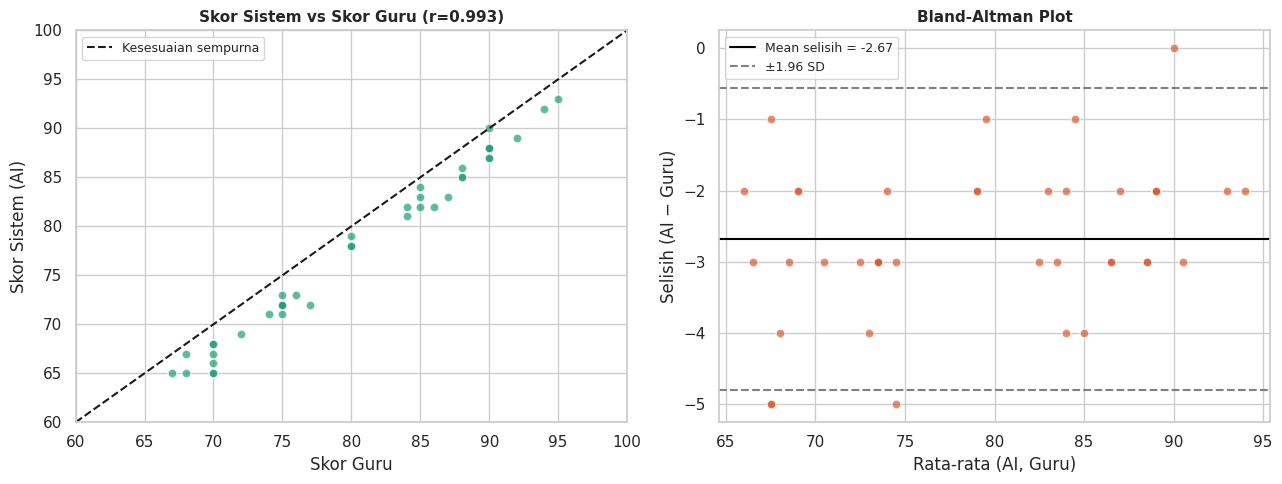

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(skor_guru_val, skor_ai_val, alpha=0.7, color='#1D9E75', edgecolor='white', s=40)
lims = [min(skor_guru_val.min(), skor_ai_val.min()) - 5,
        max(skor_guru_val.max(), skor_ai_val.max()) + 5]
axes[0].plot(lims, lims, 'k--', label='Kesesuaian sempurna')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Skor Guru')
axes[0].set_ylabel('Skor Sistem (AI)')
axes[0].set_title(f'Skor Sistem vs Skor Guru (r={pearson_val_r:.3f})', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

mean_skor_val = (skor_ai_val + skor_guru_val) / 2
axes[1].scatter(mean_skor_val, selisih_val, alpha=0.7, color='#D85A30', edgecolor='white', s=40)
axes[1].axhline(selisih_val.mean(), color='black', linestyle='-',
                label=f'Mean selisih = {selisih_val.mean():.2f}')
axes[1].axhline(selisih_val.mean() + 1.96 * selisih_val.std(), color='gray', linestyle='--', label='±1.96 SD')
axes[1].axhline(selisih_val.mean() - 1.96 * selisih_val.std(), color='gray', linestyle='--')
axes[1].set_xlabel('Rata-rata (AI, Guru)')
axes[1].set_ylabel('Selisih (AI − Guru)')
axes[1].set_title('Bland-Altman Plot', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eval_validasi_eksternal.png', dpi=150, bbox_inches='tight')
plt.show()

hasil_validasi_eksternal = {
    'n_sampel'        : len(df_validasi),
    'pearson_r'       : pearson_val_r,
    'pearson_p'       : pearson_val_p,
    'spearman_r'      : spearman_val_r,
    'mae'             : mae_val,
    'rmse'            : rmse_val,
    'rata_selisih'    : selisih_val.mean(),
    't_p'             : t_p_val,
    'agreement_pct'   : agreement_val,
    'cohen_kappa'     : kappa_val,
    'confusion_matrix': cm_val,
    'df_validasi'     : df_validasi,
}

### 13.5 Ringkasan Evaluasi

In [ ]:
print('=' * 70)
print('RINGKASAN EVALUASI SISTEM AES')
print('=' * 70)

print('\n[ KELOMPOK 1 — EMBEDDING QUALITY ]')
print(f'  Intra-class Similarity : {hasil_embedding_quality["intra_class_mean"]:.4f}')
print(f'  Inter-class Similarity : {hasil_embedding_quality["inter_class_mean"]:.4f}')
print(f'  Discriminative Gap     : {hasil_embedding_quality["discriminative_gap"]:.4f}  {"✅" if hasil_embedding_quality["discriminative_gap"] > 0 else "⚠️"}')
print(f'  Mean Cohesion          : {hasil_embedding_quality["mean_cohesion"]:.4f}')

print('\n[ KELOMPOK 2 — SCORING CONSISTENCY ]')
for topik, alpha in hasil_cronbach.items():
    print(f'  Cronbach Alpha [{topik[:18]}] : {alpha:.4f}  {"✅" if alpha >= 0.70 else "⚠️"}')

print('\n[ KELOMPOK 3 — PERBANDINGAN MODEL ]')
print(f'  Bias panjang — Model A : r={hasil_embedding_quality["korelasi_skor_panjang_r_model_a"]:.4f}')
print(f'  Bias panjang — Model B : r={hasil_embedding_quality["korelasi_skor_panjang_r"]:.4f}')
print(f'  Pearson A vs B         : {hasil_embedding_quality["pearson_model_a_vs_b"]:.4f}')
if hasil_model_comparison:
    print(f"  Pearson vs Guru [A]    : {hasil_model_comparison['model_a']['pearson_r']:.4f}")
    print(f"  Pearson vs Guru [B]    : {hasil_model_comparison['model_b']['pearson_r']:.4f}")

print('\n[ KELOMPOK 4 — VALIDASI EKSTERNAL ]')
print(f'  Sampel validasi        : {hasil_validasi_eksternal["n_sampel"]}')
print(f'  Pearson r vs Guru      : {hasil_validasi_eksternal["pearson_r"]:.4f}')
print(f'  MAE / RMSE             : {hasil_validasi_eksternal["mae"]:.2f} / {hasil_validasi_eksternal["rmse"]:.2f}')
print(f'  Kesesuaian kategori    : {hasil_validasi_eksternal["agreement_pct"]*100:.1f}%')
print(f"  Cohen's Kappa          : {hasil_validasi_eksternal['cohen_kappa']:.4f}")

print('\n[ STATISTIK SKOR AES KESELURUHAN ]')
print(f'  Total data  : {len(df):,}')
print(f'  Mean        : {df["skor_aes"].mean():.2f}')
print(f'  Median      : {df["skor_aes"].median():.2f}')
print(f'  Std         : {df["skor_aes"].std():.2f}')
print(f'  Min / Max   : {df["skor_aes"].min():.2f} / {df["skor_aes"].max():.2f}')

RINGKASAN EVALUASI SISTEM AES

[ KELOMPOK 1 — EMBEDDING QUALITY ]
  Intra-class Similarity : 0.7319
  Inter-class Similarity : 0.5092
  Discriminative Gap     : 0.2227  ✅
  Mean Cohesion          : 0.8562

[ KELOMPOK 2 — SCORING CONSISTENCY ]
  Cronbach Alpha [Kolonialisme & Per] : 0.5580  ⚠️
  Cronbach Alpha [Pendudukan Jepang] : 0.6564  ⚠️

[ KELOMPOK 3 — PERBANDINGAN MODEL ]
  Bias panjang — Model A : r=0.7241
  Bias panjang — Model B : r=0.6435
  Pearson A vs B         : 0.9022
  Cohen's Kappa A vs B   : 0.0000

[ KELOMPOK 4 — VALIDASI EKSTERNAL ]
  Sampel validasi        : 40
  Pearson r vs Guru      : 0.9929
  MAE / RMSE             : 2.67 / 2.89
  Kesesuaian kategori    : 92.5%
  Cohen's Kappa          : 0.8507

[ STATISTIK SKOR AES KESELURUHAN ]
  Total data  : 1,175
  Mean        : 75.20
  Median      : 76.79
  Std         : 10.67
  Min / Max   : 27.55 / 96.32


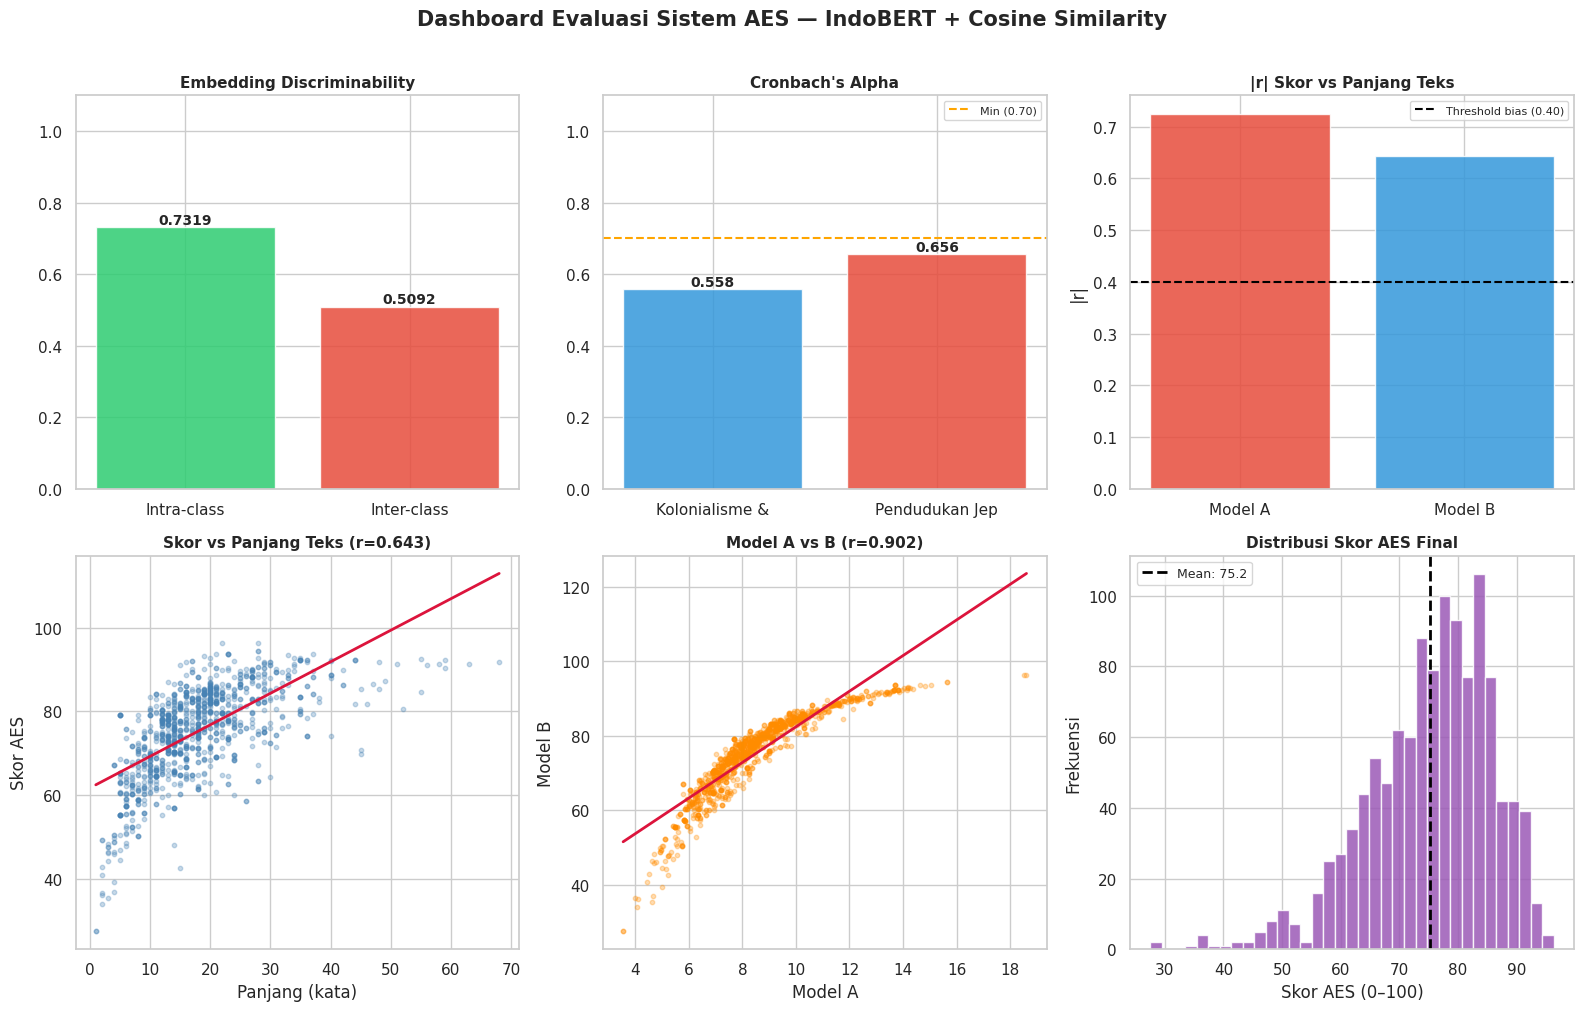

In [ ]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Dashboard Evaluasi Sistem AES — IndoBERT + Cosine Similarity',
             fontsize=15, fontweight='bold', y=1.01)
ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

bars_ = ax1.bar(['Intra-class', 'Inter-class'], [mean_intra, mean_inter],
                color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white')
for b_, v_ in zip(bars_, [mean_intra, mean_inter]):
    ax1.text(b_.get_x() + b_.get_width()/2, b_.get_height()+0.01,
             f'{v_:.4f}', ha='center', fontweight='bold', fontsize=10)
ax1.set_title('Embedding Discriminability', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.1)

alpha_bars = ax2.bar([t[:14] for t in hasil_cronbach.keys()], list(hasil_cronbach.values()),
                     color=['#3498db', '#e74c3c'][:len(hasil_cronbach)], alpha=0.85, edgecolor='white')
for b_, v_ in zip(alpha_bars, hasil_cronbach.values()):
    ax2.text(b_.get_x()+b_.get_width()/2, b_.get_height()+0.01,
             f'{v_:.3f}', ha='center', fontweight='bold', fontsize=10)
ax2.axhline(0.70, color='orange', linestyle='--', linewidth=1.5, label='Min (0.70)')
ax2.set_title("Cronbach's Alpha", fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=8)

ax3.bar(['Model A', 'Model B'], [abs(r_all_a), abs(r_all)], color=['#e74c3c', '#3498db'], alpha=0.85)
ax3.axhline(0.40, color='black', linestyle='--', label='Threshold bias (0.40)')
ax3.set_title('|r| Skor vs Panjang Teks', fontsize=11, fontweight='bold')
ax3.set_ylabel('|r|')
ax3.legend(fontsize=8)

ax4.scatter(df['panjang_jawaban_siswa'], df['skor_aes'], alpha=0.3, s=10, color='steelblue')
m4, b4 = np.polyfit(df['panjang_jawaban_siswa'], df['skor_aes'], 1)
x4 = np.linspace(df['panjang_jawaban_siswa'].min(), df['panjang_jawaban_siswa'].max(), 100)
ax4.plot(x4, m4*x4+b4, color='crimson', linewidth=2)
ax4.set_title(f'Skor vs Panjang Teks (r={r_all:.3f})', fontsize=11, fontweight='bold')
ax4.set_xlabel('Panjang (kata)')
ax4.set_ylabel('Skor AES')

ax5.scatter(df['skor_model_a_indobert_saja'], df['skor_aes'], alpha=0.3, s=10, color='darkorange')
m5, b5 = np.polyfit(df['skor_model_a_indobert_saja'], df['skor_aes'], 1)
x5 = np.linspace(df['skor_model_a_indobert_saja'].min(), df['skor_model_a_indobert_saja'].max(), 100)
ax5.plot(x5, m5*x5+b5, color='crimson', linewidth=2)
ax5.set_title(f'Model A vs B (r={r_ab_pearson:.3f})', fontsize=11, fontweight='bold')
ax5.set_xlabel('Model A')
ax5.set_ylabel('Model B')

ax6.hist(df['skor_aes'], bins=35, color='#9b59b6', edgecolor='white', alpha=0.85)
ax6.axvline(df['skor_aes'].mean(), color='black', linestyle='--', linewidth=2,
            label=f'Mean: {df["skor_aes"].mean():.1f}')
ax6.set_title('Distribusi Skor AES Final', fontsize=11, fontweight='bold')
ax6.set_xlabel('Skor AES (0–100)')
ax6.set_ylabel('Frekuensi')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eval_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Simpan Hasil

In [ ]:
kolom_output = ['nama', 'kelas', 'topik', 'id_pertanyaan', 'pertanyaan',
                 'jawaban_siswa', 'kunci_jawaban', 'cosine_similarity', 'skor_aes', 'kategori']
df_output = df[kolom_output].copy().sort_values(['kelas', 'nama', 'topik', 'id_pertanyaan'])

with pd.ExcelWriter('Hasil_AES_IndoBERT_Cosine.xlsx', engine='openpyxl') as writer:
    df_output.to_excel(writer, sheet_name='Semua Hasil', index=False)
    rekap_siswa.to_excel(writer, sheet_name='Rekap per Siswa', index=False)
    ringkasan_soal.drop(columns=['pertanyaan']).to_excel(writer, sheet_name='Ringkasan per Soal', index=False)

print('✓ Hasil disimpan ke: Hasil_AES_IndoBERT_Cosine.xlsx')

ringkasan_json = {
    'model'               : INDOBERT_MODEL_NAME,
    'embedding_strategy'  : EMBEDDING_STRATEGY,
    'total_data'          : int(len(df)),
    'jumlah_siswa'        : int(df['nama'].nunique()),
    'statistik_skor'      : {
        'mean'  : round(float(df['skor_aes'].mean()), 4),
        'median': round(float(df['skor_aes'].median()), 4),
        'std'   : round(float(df['skor_aes'].std()), 4),
        'min'   : round(float(df['skor_aes'].min()), 4),
        'max'   : round(float(df['skor_aes'].max()), 4),
    },
    'distribusi_kategori' : df['kategori'].value_counts().to_dict(),
    'skor_rata_per_kelas' : df.groupby('kelas')['skor_aes'].mean().round(4).to_dict(),
    'skor_rata_per_topik' : df.groupby('topik')['skor_aes'].mean().round(4).to_dict(),
}
with open('ringkasan_aes.json', 'w', encoding='utf-8') as f:
    json.dump(ringkasan_json, f, ensure_ascii=False, indent=2)
print('✓ Ringkasan disimpan ke: ringkasan_aes.json')

✓ Hasil disimpan ke: Hasil_AES_IndoBERT_Cosine.xlsx
✓ Ringkasan disimpan ke: ringkasan_aes.json


## 15. Simpan Model Pipeline (.pkl)

In [ ]:
import joblib

pipeline_payload = {
    'model_name'         : INDOBERT_MODEL_NAME,
    'embedding_strategy' : EMBEDDING_STRATEGY,
    'max_length'         : MAX_LENGTH,
    'score_min'          : SCORE_MIN,
    'score_max'          : SCORE_MAX,
    'thresholds'         : {'sangat_sesuai': THRESHOLD_TINGGI,
                            'cukup_sesuai' : THRESHOLD_SEDANG,
                            'kurang_sesuai': THRESHOLD_RENDAH},
    'preprocessor'       : preprocessor,
    'kunci_unik'         : kunci_unik,
    'df_hasil'           : df[[
        'nama', 'kelas', 'topik', 'id_pertanyaan', 'pertanyaan',
        'jawaban_siswa', 'kunci_jawaban', 'cosine_similarity', 'skor_aes', 'kategori',
        'panjang_jawaban_siswa', 'euclidean_distance',
        'skor_model_a_indobert_saja', 'kategori_model_a'
    ]].copy(),
    'rekap_siswa'        : rekap_siswa.copy(),
    'ringkasan_soal'     : ringkasan_soal.copy(),
    'hasil_evaluasi'     : {
        'embedding_quality' : hasil_embedding_quality,
        'intra_scores'      : intra_scores,
        'inter_scores'      : inter_scores,
        'df_cohesion'       : df_cohesion,
        'cronbach_alpha'    : hasil_cronbach,
        'df_sensitivity'    : df_sensitivity,
        'r_skor_panjang'    : r_all,
        'r_skor_panjang_a'  : r_all_a,
        'perbandingan_model': hasil_model_comparison,
        'validasi_eksternal': hasil_validasi_eksternal,
    },
}

joblib.dump(pipeline_payload, 'aes_pipeline.pkl', compress=3)
size_mb = os.path.getsize('aes_pipeline.pkl') / (1024 * 1024)
print(f'✅ Pipeline disimpan: aes_pipeline.pkl ({size_mb:.2f} MB)')

✅ Pipeline disimpan: aes_pipeline.pkl (0.09 MB)


In [ ]:
pipeline_loaded = joblib.load('aes_pipeline.pkl')
assert pipeline_loaded['model_name'] == INDOBERT_MODEL_NAME
assert len(pipeline_loaded['kunci_unik']) == len(kunci_unik)
assert len(pipeline_loaded['df_hasil'])   == len(df)
print('✅ Verifikasi pipeline berhasil.')
print('Jalankan app: streamlit run app.py')

✅ Verifikasi pipeline berhasil.
Jalankan app: streamlit run app.py
